# Demo 4 — Grating-evoked activity (2-D sheet)

A drifting-free (static) oriented grating on a 2-D sheet. We show how the evoked
response map changes with the recurrent gain, and how a fixed network responds to
gratings of different orientations.

In [1]:
# --- make the package importable ---------------------------------------------
# The package files live flat in the repository folder (itself named
# "cortical_rate_model"), so we add its PARENT directory to the path.
# Walking up from the working directory lets this notebook run from the
# demos/ folder, from the repository root, or from anywhere inside the repo.
import sys, pathlib
_cwd = pathlib.Path.cwd()
for _p in (_cwd, *_cwd.parents):
    if _p.name == "cortical_rate_model" and (_p / "network.py").exists():
        sys.path.insert(0, str(_p.parent))
        break
else:
    raise RuntimeError("Could not locate the cortical_rate_model package directory.")


import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import cortical_rate_model as crm
from cortical_rate_model import Layout, RateNetwork, EIRateNetwork, make_connectivity, inputs, plotting
print("cortical_rate_model", crm.__version__)

cortical_rate_model 0.1.0


In [2]:
def build_net(kind, layout, spectral_radius=0.97, nonlinearity="rectification", **params):
    """Single-population network with its recurrent gain set by spectral radius."""
    W = make_connectivity(kind, layout, **params)
    W = crm.scale_spectral_radius(W, spectral_radius)
    return RateNetwork(W, layout=layout, nonlinearity=nonlinearity)

def build_ei(layout, spectral_radius=0.97, nonlinearity="rectification", **params):
    """Two-population E/I network with its recurrent gain set by spectral radius."""
    W, meta = make_connectivity("ei_homogeneous", layout, normalise="spectral",
                                spectral_radius=spectral_radius, **params)
    return EIRateNetwork(W, meta=meta, layout=layout, nonlinearity=nonlinearity)

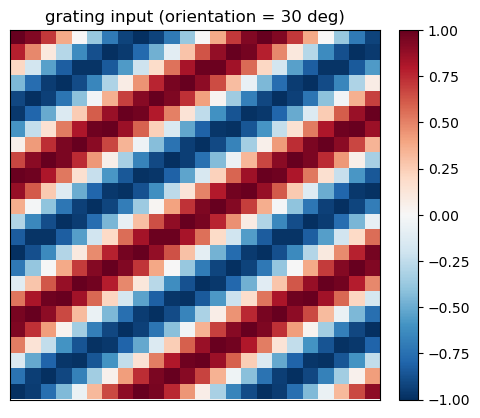

In [3]:
sheet = Layout((24, 24), periodic=True)
grating = inputs.oriented_grating(sheet, wavelength=8.0, orientation=np.pi / 6,
                                  amplitude=1.0)
plotting.plot_pattern(grating, sheet, title="grating input (orientation = 30 deg)")
plt.show()

## Sweep the recurrent gain

Increasing spectral radius amplifies the grating-aligned recurrent modes.

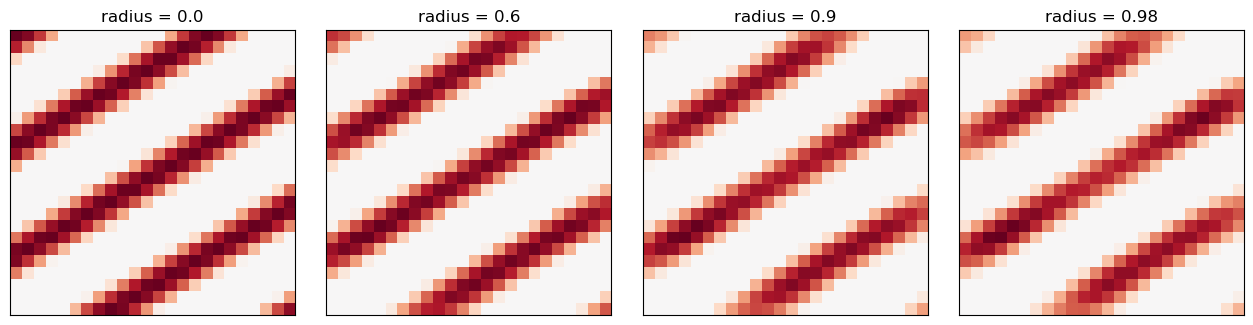

In [4]:
radii = [0.0, 0.6, 0.9, 0.98]
fig, axes = plt.subplots(1, len(radii), figsize=(3.2 * len(radii), 3.2))
for ax, radius in zip(axes, radii):
    net = build_net("mexican_hat", sheet, spectral_radius=max(radius, 1e-6),
                    sigma=1.8, inh_factor=2.5)
    r = net.steady_state(grating, n_steps=400)
    plotting.plot_pattern(r, sheet, ax=ax, colorbar=False,
                          title=f"radius = {radius}")
plt.tight_layout(); plt.show()

## Response to different grating orientations

A single homogeneous network, gratings at several orientations.

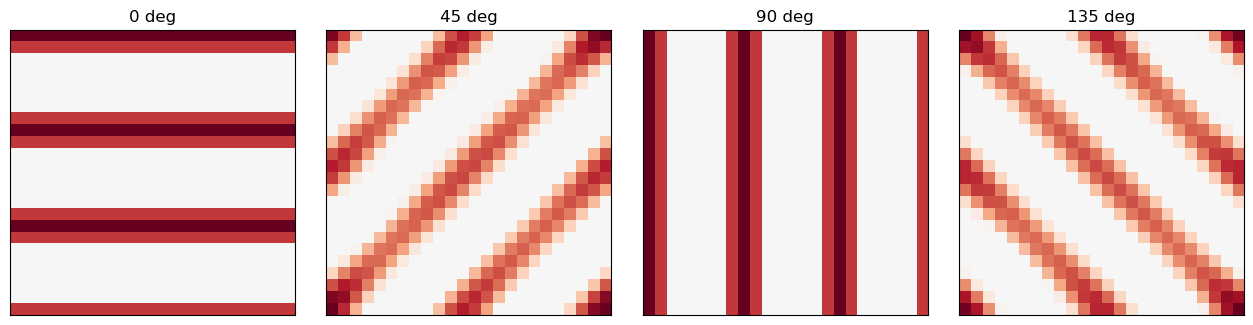

In [5]:
net = build_net("mexican_hat", sheet, spectral_radius=0.95, sigma=1.8, inh_factor=2.5)
orients = np.linspace(0, np.pi, 4, endpoint=False)
fig, axes = plt.subplots(1, len(orients), figsize=(3.2 * len(orients), 3.2))
for ax, ori in zip(axes, orients):
    g = inputs.oriented_grating(sheet, wavelength=8.0, orientation=ori, amplitude=1.0)
    r = net.steady_state(g, n_steps=400)
    plotting.plot_pattern(r, sheet, ax=ax, colorbar=False,
                          title=f"{np.degrees(ori):.0f} deg")
plt.tight_layout(); plt.show()